## Block 1: Imports and Global Config

Imports core dependencies and defines all configurable experiment variables in one place.


In [36]:
import os, sys, json, csv, math, time, subprocess, warnings, re
from pathlib import Path

import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings(
    "ignore",
    message="enable_nested_tensor is True",
    module="torch.nn.modules.transformer"
)

# ---------------- Global Config (edit here) ----------------
# Runtime / environment
PREFERRED_GPU_INDEX = 1
# If non-empty, use exactly these CUDA device indices (e.g., [0, 1]).
CUDA_DEVICE_INDICES = [0,1,2]
# Set to "auto", "cuda", "mps", or "cpu".
DEVICE_OVERRIDE = "auto"
AUTO_INSTALL_PACKAGES = ("optuna", "tqdm", "matplotlib", "spikingjelly", "torchmetrics", "scikit-learn", "pandas", "numpy", "torch", "seaborn", "xformers", "ipywidgets")

# Experiment identity and paths
EXPERIMENT_TAG = "VIII"
RESULTS_DIR = Path(".")
DATASET_DIR = Path("baf-datasets")
DATASET_FILE_NAME = f"{EXPERIMENT_TAG}.csv"
DATA_CSV_PATH = DATASET_DIR / DATASET_FILE_NAME
EXPORT_DIR = RESULTS_DIR / f"snn_ftt_100_export_{EXPERIMENT_TAG}"

# Dataset schema / split controls
TARGET_CANDIDATE_COLUMNS = ["fraud_bool", "fraud", "is_fraud", "label", "target"]
MONTH_COLUMN = "month"
TRAIN_MONTH_MAX = 5
TEST_MONTH_MIN = 6
VALID_SPLIT_RATIO = 0.2
DROP_FEATURE_NAME_FRAGMENTS = {"customer", "id", "uuid"}
INT_AS_CATEGORICAL_MAX_UNIQUE = 50
AGE_GROUP_COLUMNS = ["age", "Age", "AGE", "age_group"]
AGE_THRESHOLD = 50

# Training / optimization controls
RANDOM_SEED = 42
WEIGHT_DECAY = 1e-5
FPR_CAP = 0.05
EPSILON = 1e-12
FAIRNESS_RATIO_SMOOTHING = 1e-3

# 2-stage + joint refinement schedule
STAGE_A_TRIALS = 80
STAGE_B_TRIALS = 100
STAGE_C_TRIALS = 40
STAGE_A_EPOCHS = 8
STAGE_B_EPOCHS = 8
STAGE_C_EPOCHS = 10
FINAL_EPOCHS = 20
EARLY_STOP_PATIENCE = 3
PRUNER_STARTUP_TRIALS = 8
PRUNER_WARMUP_STEPS = 2

OPTUNA_DIRECTION = "maximize"
OPTUNA_STUDY_NAME = f"joint_snn_ftt_recall_at_fpr_cap_{EXPERIMENT_TAG}"
OPTUNA_STORAGE_PATH = RESULTS_DIR / f"optuna_{OPTUNA_STUDY_NAME}.db"
OPTUNA_STORAGE_URL = f"sqlite:///{OPTUNA_STORAGE_PATH.resolve()}"
OPTUNA_LOAD_IF_EXISTS = True
VALID_TEST_BATCH_MULTIPLIER = 2
DEFAULT_THRESHOLD = 0.5
# Set True to populate per-trial test metrics in the fairness CSV.
# Set False if you want strict no-test-peeking during tuning.
LOG_TEST_DURING_TUNING = True

# Hyperparameter search space (Transformer + optimizer)
HP_D_TOKEN_CHOICES = [16, 32, 48, 64]
HP_N_BLOCKS_MIN = 2
HP_N_BLOCKS_MAX = 6
HP_N_HEADS_CHOICES = [4, 8]
HP_FFN_HIDDEN_CHOICES = [64, 128, 192, 256]
HP_DROPOUT_MIN = 0.0
HP_DROPOUT_MAX = 0.4
HP_LR_MIN = 3e-4
HP_LR_MAX = 3e-3
HP_BATCH_CHOICES = [1024, 2048, 4096, 8192]

# SNN head search space (used in Stage B and Stage C)
SNN_HP_T_CHOICES = [4, 6, 8, 10, 12]
SNN_HP_TAU_MIN = 1.5
SNN_HP_TAU_MAX = 4.0
SNN_HP_V_THRESHOLD_MIN = 0.1
SNN_HP_V_THRESHOLD_MAX = 0.5
SNN_HP_V_RESET_CHOICES = [0.0]
SNN_HP_ALPHA_INIT_MIN = 1.1
SNN_HP_ALPHA_INIT_MAX = 6.0
SNN_HP_HEAD_DROPOUT_MIN = 0.0
SNN_HP_HEAD_DROPOUT_MAX = 0.4

# Stage C local refinement controls
STAGE_C_NEIGHBOR_RADIUS = 1
STAGE_C_LOCAL_FRACTION = 0.30
STAGE_C_LR_LOG10_RADIUS = 0.35

# Model defaults
FT_DEFAULT_D_TOKEN = 32
FT_DEFAULT_N_BLOCKS = 4
FT_DEFAULT_N_HEADS = 8
FT_DEFAULT_FFN_HIDDEN = 128
FT_DEFAULT_DROPOUT = 0.2
SNN_HEAD_T = 8
SNN_HEAD_TAU = 2.0
SNN_HEAD_V_THRESHOLD = 0.2
SNN_HEAD_V_RESET = 0.0
SNN_HEAD_DROPOUT = 0.1
SNN_HEAD_ALPHA_INIT = 2.0

# Logs and exports
TRIALS_CSV = RESULTS_DIR / f"snn_ftt_100_trials_{EXPERIMENT_TAG}.csv"
BEST_CSV = RESULTS_DIR / f"snn_ftt_100_trials_best_{EXPERIMENT_TAG}.csv"
FAIR_CSV = RESULTS_DIR / f"snn_ftt_100_trials_fairness_{EXPERIMENT_TAG}.csv"
TRIAL_LOG_FIELDS = [
    "stage", "trial", "epoch",
    "d_token", "n_blocks", "n_heads", "ffn_hidden", "dropout",
    "snn_T", "snn_tau", "snn_v_threshold", "snn_v_reset", "snn_head_dropout", "snn_alpha_init",
    "lr", "batch",
    "val_auc", "val_prauc", "val_recall_at_fpr", "val_fpr", "val_threshold"
]
FAIR_LOG_FIELDS = [
    "stage", "trial", "perf_recall_test", "fairness_ratio_test", "thr_star", "fpr_test",
    "recall_val", "fpr_val", "fairness_ratio_val"
]

# Plot controls
PLOT_FIGSIZE = (7.0, 5.0)
PLOT_DPI = 150
TOP_K_TRIALS = 5
ZOOM_X_QUANTILE = 0.6
ZOOM_Y_LOW_QUANTILE = 0.05
ZOOM_Y_HIGH_QUANTILE = 0.95


## Block 2: Device Selection

Uses `DEVICE_OVERRIDE` (`"auto"`, `"cuda"`, `"mps"`, `"cpu"`) to select runtime hardware.
In `"auto"` mode, priority is CUDA -> MPS -> CPU.


In [37]:
# ---------------- Repro/Device ----------------
# Device selection policy:
# - DEVICE_OVERRIDE = "auto": CUDA -> MPS -> CPU
# - DEVICE_OVERRIDE = "cuda"/"mps"/"cpu": force a backend if available (fallback with warning)
# - If CUDA_DEVICE_INDICES is non-empty, use exactly those GPUs (first becomes active device)

device_override_normalized = str(DEVICE_OVERRIDE).strip().lower()
if device_override_normalized not in {"auto", "cuda", "mps", "cpu"}:
    print(f'Warning: DEVICE_OVERRIDE="{DEVICE_OVERRIDE}" is invalid; falling back to "auto".')
    device_override_normalized = "auto"

cuda_available = torch.cuda.is_available()
mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

def _resolve_cuda_indices():
    if not CUDA_DEVICE_INDICES:
        return None
    valid = []
    max_idx = torch.cuda.device_count() - 1
    for idx in CUDA_DEVICE_INDICES:
        if isinstance(idx, (int, np.integer)) and 0 <= int(idx) <= max_idx:
            valid.append(int(idx))
        else:
            print(f"Warning: CUDA_DEVICE_INDICES contains invalid index {idx}; skipping.")
    if not valid:
        print("Warning: CUDA_DEVICE_INDICES is set but no valid indices remain; falling back to default selection.")
        return None
    return valid

selected_gpu_indices = None
selected_gpu_index = None
if device_override_normalized == "cuda":
    if cuda_available:
        selected_gpu_indices = _resolve_cuda_indices()
        if selected_gpu_indices is None:
            selected_gpu_index = min(PREFERRED_GPU_INDEX, torch.cuda.device_count() - 1)
            selected_gpu_indices = [selected_gpu_index]
        else:
            selected_gpu_index = selected_gpu_indices[0]
        torch.cuda.set_device(selected_gpu_index)
        active_device = torch.device(f"cuda:{selected_gpu_index}")
        selected_accelerator = "cuda"
    else:
        print("Warning: CUDA requested but not available; using CPU.")
        active_device = torch.device("cpu")
        selected_accelerator = "cpu"
elif device_override_normalized == "mps":
    if mps_available:
        active_device = torch.device("mps")
        selected_accelerator = "mps"
    else:
        print("Warning: MPS requested but not available; using CPU.")
        active_device = torch.device("cpu")
        selected_accelerator = "cpu"
elif device_override_normalized == "cpu":
    active_device = torch.device("cpu")
    selected_accelerator = "cpu"
else:
    if cuda_available:
        selected_gpu_indices = _resolve_cuda_indices()
        if selected_gpu_indices is None:
            selected_gpu_index = min(PREFERRED_GPU_INDEX, torch.cuda.device_count() - 1)
            selected_gpu_indices = [selected_gpu_index]
        else:
            selected_gpu_index = selected_gpu_indices[0]
        torch.cuda.set_device(selected_gpu_index)
        active_device = torch.device(f"cuda:{selected_gpu_index}")
        selected_accelerator = "cuda"
    elif mps_available:
        active_device = torch.device("mps")
        selected_accelerator = "mps"
    else:
        active_device = torch.device("cpu")
        selected_accelerator = "cpu"

print(f'Torch {torch.__version__} | DEVICE_OVERRIDE: {DEVICE_OVERRIDE} | Device: {active_device}')
if selected_accelerator == "cuda":
    print("Current GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))
    if selected_gpu_indices and len(selected_gpu_indices) > 1:
        print("CUDA_DEVICE_INDICES:", selected_gpu_indices)
elif selected_accelerator == "mps":
    print("Using Apple Silicon MPS accelerator.")
else:
    print("Using CPU backend.")


# Helper: wrap model for multi-GPU when CUDA_DEVICE_INDICES has >1 entries
def maybe_wrap_dataparallel(model):
    if selected_accelerator == "cuda" and selected_gpu_indices and len(selected_gpu_indices) > 1:
        return nn.DataParallel(model, device_ids=selected_gpu_indices)
    return model


Torch 2.10.0+cu128 | DEVICE_OVERRIDE: auto | Device: cuda:0
Current GPU: NVIDIA RTX A6000
CUDA_DEVICE_INDICES: [0, 1, 2]


## Block 3: Optimizer Dynamo Patch

Applies a compatibility patch for Optimizer methods to avoid torch._dynamo issues on some environments.


In [38]:
# Compatibility workaround: some Torch builds fail while importing torch._dynamo
# via @torch._disable_dynamo wrappers used in optimizer methods.
def patch_optimizer_dynamo_wrappers():
    optimizer_class = torch.optim.Optimizer
    method_names = ["add_param_group", "zero_grad", "state_dict", "load_state_dict"]
    for method_name in method_names:
        wrapped_method = getattr(optimizer_class, method_name, None)
        raw_method = getattr(wrapped_method, "__wrapped__", None)
        if raw_method is not None and not hasattr(raw_method, "__dynamo_disable"):
            raw_method.__dynamo_disable = raw_method

patch_optimizer_dynamo_wrappers()


## Block 4: Adam Step Patch

Unwraps Adam/AdamW step wrappers to prevent runtime failures caused by problematic dynamo hooks.


In [39]:
# Additional compatibility patch: unwrap Adam/AdamW step to avoid `_use_grad`
# importing torch._dynamo at runtime on affected builds.
def patch_adam_step_wrappers():
    for optimizer_class in [torch.optim.Adam, torch.optim.AdamW]:
        step_fn = getattr(optimizer_class, "step", None)
        while hasattr(step_fn, "__wrapped__"):
            step_fn = step_fn.__wrapped__
        optimizer_class.step = step_fn
        # Prevent Optimizer._patch_step_function from wrapping this again.
        optimizer_class.step.hooked = True

patch_adam_step_wrappers()


## Block 5: Optional Package Setup

Checks for required packages and installs missing ones, then imports Optuna, tqdm, matplotlib, and torch.nn.functional.


In [40]:
# Install optional runtime dependencies if missing.
for package_name in AUTO_INSTALL_PACKAGES:
    try:
        __import__(package_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
import optuna
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
import types

## Block 6: SpikingJelly Import Fallback

Imports SpikingJelly components; if import fails, defines a local fallback LIF node implementation.


In [41]:
# --- SNN imports (SpikingJelly) ---
# Compatibility workaround: some torch/spikingjelly builds fail when TorchScript
# compiles surrogate SoftSign during import.
_original_torch_jit_script = torch.jit.script

def _safe_torch_jit_script(obj=None, *args, **kwargs):
    if obj is None:
        def _decorator(fn):
            return _safe_torch_jit_script(fn, *args, **kwargs)
        return _decorator
    try:
        return _original_torch_jit_script(obj, *args, **kwargs)
    except Exception as error:
        error_text = str(error)
        if "softsign" in error_text and "Argument lower not provided" in error_text:
            return obj
        raise

torch.jit.script = _safe_torch_jit_script
try:
    from spikingjelly.activation_based import neuron, surrogate, functional
except Exception as import_error:
    print(f"Warning: SpikingJelly import failed ({import_error}). Using local LIF fallback.")

    class _FallbackLIFNode(nn.Module):
        def __init__(self, tau=2.0, v_threshold=0.2, v_reset=0.0, surrogate_function=None, detach_reset=True):
            super().__init__()
            self.tau = float(tau)
            self.v_threshold = float(v_threshold)
            self.v_reset = float(v_reset)
            self.v = None

        def reset(self):
            self.v = None

        def forward(self, x):
            if self.v is None or self.v.shape != x.shape:
                self.v = torch.zeros_like(x)
            self.v = self.v + (x - self.v) / self.tau
            spikes = (self.v >= self.v_threshold).to(x.dtype)
            self.v = torch.where(spikes > 0, torch.full_like(self.v, self.v_reset), self.v)
            return spikes

    neuron = types.SimpleNamespace(LIFNode=_FallbackLIFNode)
    surrogate = types.SimpleNamespace(ATan=lambda: None)
    functional = types.SimpleNamespace(
        reset_net=lambda module: module.reset() if hasattr(module, "reset") else None
    )
finally:
    torch.jit.script = _original_torch_jit_script


## Block 7: Experiment Configuration

Defines paths, random seed, optimization settings, logging schemas, and export configuration.


In [42]:
# ---------------- Config ----------------
# Reproducibility and runtime summary
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Torch {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device: {active_device}")
if active_device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))
elif active_device.type == "mps":
    print("MPS backend active.")
else:
    print("CPU backend active.")

print(f"Experiment tag : {EXPERIMENT_TAG}")
print(f"Dataset path   : {DATA_CSV_PATH}")
print(f"Export dir     : {EXPORT_DIR}")
print(f"Trials CSV     : {TRIALS_CSV}")
print(f"Stage schedule : A={STAGE_A_TRIALS} / B={STAGE_B_TRIALS} / C={STAGE_C_TRIALS} trials")
print(f"Epochs         : A={STAGE_A_EPOCHS} / B={STAGE_B_EPOCHS} / C={STAGE_C_EPOCHS} | Final retrain={FINAL_EPOCHS}")


Torch 2.10.0+cu128 | CUDA: True | Device: cuda:0
GPU: NVIDIA RTX A6000
Experiment tag : VIII
Dataset path   : baf-datasets/VIII.csv
Export dir     : snn_ftt_100_export_VIII
Trials CSV     : snn_ftt_100_trials_VIII.csv
Stage schedule : A=80 / B=100 / C=40 trials
Epochs         : A=8 / B=8 / C=10 | Final retrain=20


## Block 8: Dataset Loading

Resolves the dataset path and loads the selected CSV into a dataframe.


In [43]:
# ---------------- Data prep ----------------
def resolve_dataset_path(raw_path: Path) -> Path:
    # Allow both direct path and fallback to configured dataset folder.
    candidate_paths = [
        raw_path,
        Path(DATASET_FILE_NAME),
        DATASET_DIR / DATASET_FILE_NAME,
    ]
    for candidate_path in candidate_paths:
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(
        f"Dataset not found. Tried: {', '.join(str(path) for path in candidate_paths)}"
    )


DATA_CSV_PATH = resolve_dataset_path(DATA_CSV_PATH)
full_df = pd.read_csv(DATA_CSV_PATH)

## Block 9: Target and Time Split

Finds target column, validates month field, parses month values, and creates train/valid vs test time splits.


In [44]:
# Detect the target column from common names.
for candidate_target_col in TARGET_CANDIDATE_COLUMNS:
    if candidate_target_col in full_df.columns:
        target_col = candidate_target_col
        break
else:
    raise ValueError(f"Set target column name. Tried: {TARGET_CANDIDATE_COLUMNS}")

# Time split by month: <= TRAIN_MONTH_MAX for train/valid, >= TEST_MONTH_MIN for test.
if MONTH_COLUMN not in full_df.columns:
    raise ValueError(f"Expected a '{MONTH_COLUMN}' column for time-based split.")


def parse_int_from_value(value):
    try:
        return int(re.findall(r"-?\d+", str(value))[0])
    except Exception:
        return np.nan


month_values = full_df[MONTH_COLUMN].map(parse_int_from_value)
if month_values.isna().any():
    raise ValueError(f"Could not parse some '{MONTH_COLUMN}' values as integers.")
full_df = full_df.assign(**{MONTH_COLUMN: month_values.astype(int)})

train_valid_df = full_df[full_df[MONTH_COLUMN] <= TRAIN_MONTH_MAX].copy()
test_df = full_df[full_df[MONTH_COLUMN] >= TEST_MONTH_MIN].copy()
if len(train_valid_df) == 0 or len(test_df) == 0:
    raise ValueError(
        f"Time split produced empty train/valid or test set. Check '{MONTH_COLUMN}' range in CSV."
    )

## Block 10: Feature Typing

Builds feature list and separates columns into categorical and continuous feature groups.


In [45]:
# Build feature lists.
feature_cols = [
    column_name
    for column_name in full_df.columns
    if column_name != target_col
    and column_name != MONTH_COLUMN
    and not any(fragment in column_name.lower() for fragment in DROP_FEATURE_NAME_FRAGMENTS)
]

categorical_cols = [
    column_name for column_name in feature_cols
    if str(full_df[column_name].dtype) in ("object", "category")
]
for column_name in feature_cols:
    if (
        column_name not in categorical_cols
        and pd.api.types.is_integer_dtype(full_df[column_name])
        and full_df[column_name].nunique() <= INT_AS_CATEGORICAL_MAX_UNIQUE
    ):
        categorical_cols.append(column_name)

continuous_cols = [
    column_name
    for column_name in feature_cols
    if column_name not in categorical_cols and pd.api.types.is_numeric_dtype(full_df[column_name])
]

## Block 11: Fairness Group Definition

Defines helper functions to derive age-based protected group masks (>=50 vs <50).


In [46]:
# Fairness groups: age >= AGE_THRESHOLD vs < AGE_THRESHOLD.
def extract_numeric_age(series: pd.Series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    numeric_text = series.astype(str).str.extract(r"(-?\d+)", expand=False)
    return pd.to_numeric(numeric_text, errors="coerce")


def make_age_group_mask(dataframe: pd.DataFrame):
    for age_column_name in AGE_GROUP_COLUMNS:
        if age_column_name in dataframe.columns:
            parsed_age = extract_numeric_age(dataframe[age_column_name])
            group_mask = (parsed_age >= AGE_THRESHOLD).astype(int)
            return group_mask.fillna(0).values.astype(int)
    return np.zeros(len(dataframe), dtype=int)

## Block 12: Train/Valid Split

Splits months 0-5 into train and validation sets and computes group masks for all splits.


In [47]:
# Split train/valid inside months <= TRAIN_MONTH_MAX.
from sklearn.model_selection import train_test_split as sklearn_train_test_split

train_df, valid_df = sklearn_train_test_split(
    train_valid_df,
    test_size=VALID_SPLIT_RATIO,
    stratify=train_valid_df[target_col],
    random_state=RANDOM_SEED,
)

train_group_mask = make_age_group_mask(train_df)
valid_group_mask = make_age_group_mask(valid_df)
test_group_mask = make_age_group_mask(test_df)

## Block 13: Category Vocab and Stats

Locks categorical vocab on train-valid data and computes continuous feature means for imputation.


In [48]:
# Lock categorical vocab on TRAIN(0-5) and reserve one UNK index per feature.
categorical_levels = {}
categorical_cardinalities = {}
for column_name in categorical_cols:
    known_levels = train_valid_df[column_name].astype("category").cat.categories
    categorical_levels[column_name] = list(known_levels)
    categorical_cardinalities[column_name] = len(known_levels) + 1  # +1 for UNK

cat_cardinalities = [categorical_cardinalities[column_name] for column_name in categorical_cols] if categorical_cols else None

# Train means for continuous features (used for imputation everywhere).
continuous_train_mean = train_valid_df[continuous_cols].astype(float).mean() if continuous_cols else None


## Block 14: Encoding Functions

Defines categorical/continuous encoders and a helper to build tensor tuples for each split.


In [49]:
def encode_categorical_features(dataframe_part: pd.DataFrame) -> torch.Tensor | None:
    if not categorical_cols:
        return None
    encoded_columns = []
    for column_name in categorical_cols:
        raw_codes = pd.Categorical(dataframe_part[column_name], categories=categorical_levels[column_name]).codes
        unknown_index = categorical_cardinalities[column_name] - 1
        safe_codes = np.where(raw_codes == -1, unknown_index, raw_codes).astype("int64")
        encoded_columns.append(safe_codes)
    stacked = np.stack(encoded_columns, axis=1) if encoded_columns else None
    return torch.as_tensor(stacked, dtype=torch.long) if stacked is not None else None


def encode_continuous_features(dataframe_part: pd.DataFrame) -> torch.Tensor | None:
    if not continuous_cols:
        return None
    numeric_values = dataframe_part[continuous_cols].astype(float).copy()
    numeric_values = numeric_values.fillna(continuous_train_mean)
    return torch.as_tensor(numeric_values.values, dtype=torch.float32)


def build_split_tensors(dataframe_part: pd.DataFrame):
    x_num = encode_continuous_features(dataframe_part)
    x_cat = encode_categorical_features(dataframe_part)
    y_target = torch.as_tensor(dataframe_part[target_col].values, dtype=torch.float32).view(-1, 1)
    return x_num, x_cat, y_target


## Block 15: Tensor Construction and Normalization

Builds tensors for train/valid/test and normalizes continuous features using train statistics.


In [50]:
# Build tensors for each split.
x_num_train, x_cat_train, y_train = build_split_tensors(train_df)
x_num_valid, x_cat_valid, y_valid = build_split_tensors(valid_df)
x_num_test, x_cat_test, y_test = build_split_tensors(test_df)

# Normalize continuous features using TRAIN stats only.
if x_num_train is not None:
    train_mean = x_num_train.mean(0, keepdim=True)
    train_std = x_num_train.std(0, keepdim=True).clamp_min(1e-6)
    x_num_train = (x_num_train - train_mean) / train_std
    if x_num_valid is not None:
        x_num_valid = (x_num_valid - train_mean) / train_std
    if x_num_test is not None:
        x_num_test = (x_num_test - train_mean) / train_std


## Block 16: Device Batch Helper

Defines helper to move a batch (numeric, categorical, target) tensors to the active device.


In [51]:
def move_batch_tensors_to_device(x_num, x_cat, y_target):
    batch_parts = []
    if x_num is not None:
        batch_parts.append(x_num.to(active_device))
    if x_cat is not None:
        batch_parts.append(x_cat.to(active_device))
    batch_parts.append(y_target.to(active_device))
    return batch_parts


# Number of numeric features used by tokenizer.
num_numeric_features = 0 if x_num_train is None else x_num_train.shape[1]


## Block 17: Feature Count and Index Checks

Computes numeric feature count and validates categorical indices against embedding cardinalities.


In [52]:
# Sanity check: ensure categorical codes never exceed embedding cardinalities.
if x_cat_train is not None:
    for column_index, column_name in enumerate(categorical_cols):
        max_seen_code = int(max(
            (int(x_cat_train[:, column_index].max().item()) if x_cat_train.numel() else 0),
            (int(x_cat_valid[:, column_index].max().item()) if x_cat_valid is not None and x_cat_valid.numel() else 0),
            (int(x_cat_test[:, column_index].max().item()) if x_cat_test is not None and x_cat_test.numel() else 0),
        ))
        assert max_seen_code < categorical_cardinalities[column_name], (
            f"Index overflow in '{column_name}': {max_seen_code} >= {categorical_cardinalities[column_name]}"
        )


## Block 18: Feature Tokenizer

Defines FeatureTokenizer that converts numeric and categorical features into token embeddings with a CLS token.


In [53]:
# ---------------- FT-Transformer with SNN Head ----------------
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num_features: int, cat_feature_cardinalities, d_token: int):
        super().__init__()
        self.n_num_features = n_num_features
        self.cat_feature_cardinalities = cat_feature_cardinalities or []
        self.d_token = d_token

        if self.n_num_features > 0:
            self.num_weight = nn.Parameter(torch.randn(self.n_num_features, d_token) * 0.02)
            self.num_bias = nn.Parameter(torch.zeros(self.n_num_features, d_token))
        else:
            self.register_parameter("num_weight", None)
            self.register_parameter("num_bias", None)

        self.cat_embeds = nn.ModuleList([
            nn.Embedding(cardinality, d_token)
            for cardinality in self.cat_feature_cardinalities
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)

    def forward(self, x_num, x_cat):
        batch_size = x_num.size(0) if x_num is not None else x_cat.size(0)
        token_blocks = []

        if x_num is not None:
            token_blocks.append(
                x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0) + self.num_bias.unsqueeze(0)
            )

        if x_cat is not None and len(self.cat_feature_cardinalities) > 0:
            cat_embeddings = [embedding(x_cat[:, idx]) for idx, embedding in enumerate(self.cat_embeds)]
            token_blocks.append(torch.stack(cat_embeddings, dim=1))

        if not token_blocks:
            raise ValueError("No features to tokenize")

        all_tokens = torch.cat(token_blocks, dim=1)
        all_tokens = torch.cat([self.cls_token.expand(batch_size, 1, -1), all_tokens], dim=1)
        return all_tokens


## Block 19: SNN Head

Defines the spiking neural head that processes CLS representation through LIF dynamics and outputs logits.


In [54]:
class SNNHead(nn.Module):
    """
    Converts CLS token [B, d] to one fraud logit [B, 1] using LIF dynamics.
    A static CLS vector is injected for T steps, membrane states are averaged,
    and a linear readout produces the final logit.
    """

    def __init__(
        self,
        d_token,
        T=SNN_HEAD_T,
        tau=SNN_HEAD_TAU,
        v_th=SNN_HEAD_V_THRESHOLD,
        v_reset=SNN_HEAD_V_RESET,
        head_dropout=SNN_HEAD_DROPOUT,
        alpha_init=SNN_HEAD_ALPHA_INIT,
    ):
        super().__init__()
        self.T = int(T)
        self.batch_norm = nn.BatchNorm1d(d_token, affine=True)
        self.input_proj = nn.Linear(d_token, d_token)
        nn.init.kaiming_normal_(self.input_proj.weight, nonlinearity="linear")
        nn.init.zeros_(self.input_proj.bias)

        self.lif = neuron.LIFNode(
            tau=float(tau),
            v_threshold=float(v_th),
            v_reset=float(v_reset),
            surrogate_function=surrogate.ATan(),
            detach_reset=True,
        )

        # Parameterize alpha through softplus(log_alpha) + 1.0 so alpha always stays > 1.0.
        alpha_minus_one = max(float(alpha_init) - 1.0, 1e-4)
        alpha_raw = math.log(math.expm1(alpha_minus_one))
        self.log_alpha = nn.Parameter(torch.tensor([alpha_raw], dtype=torch.float32))

        self.current_bias = nn.Parameter(torch.zeros(d_token))
        self.dropout = nn.Dropout(float(head_dropout))
        self.readout = nn.Linear(d_token, 1)
        nn.init.zeros_(self.readout.bias)

    def forward(self, cls_embedding):
        # Reset neuron state between mini-batches.
        try:
            functional.reset_net(self.lif)
        except Exception:
            if hasattr(self.lif, "reset"):
                self.lif.reset()

        normalized = self.batch_norm(cls_embedding)
        projected = self.input_proj(normalized)
        gain = F.softplus(self.log_alpha) + 1.0
        injected_current = projected * gain + self.current_bias

        membrane_sum = 0.0
        for _ in range(self.T):
            _ = self.lif(injected_current)
            membrane_sum = membrane_sum + self.lif.v

        membrane_avg = membrane_sum / self.T
        return self.readout(self.dropout(membrane_avg))


## Block 20: FTTransformer Model

Defines the full FT-Transformer architecture with tokenizer, transformer encoder, and SNN head.


In [55]:
class FTTransformer(nn.Module):
    def __init__(
        self,
        n_num_features,
        cat_feature_cardinalities,
        d_token=FT_DEFAULT_D_TOKEN,
        n_blocks=FT_DEFAULT_N_BLOCKS,
        n_heads=FT_DEFAULT_N_HEADS,
        ffn_hidden=FT_DEFAULT_FFN_HIDDEN,
        dropout=FT_DEFAULT_DROPOUT,
        snn_T=SNN_HEAD_T,
        snn_tau=SNN_HEAD_TAU,
        snn_v_threshold=SNN_HEAD_V_THRESHOLD,
        snn_v_reset=SNN_HEAD_V_RESET,
        snn_head_dropout=SNN_HEAD_DROPOUT,
        snn_alpha_init=SNN_HEAD_ALPHA_INIT,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_num_features, cat_feature_cardinalities, d_token)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=ffn_hidden,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        self.head = SNNHead(
            d_token=d_token,
            T=snn_T,
            tau=snn_tau,
            v_th=snn_v_threshold,
            v_reset=snn_v_reset,
            head_dropout=snn_head_dropout,
            alpha_init=snn_alpha_init,
        )

    def forward(self, x_num, x_cat):
        token_sequence = self.tokenizer(x_num, x_cat)
        encoded_tokens = self.encoder(token_sequence)
        cls_embedding = encoded_tokens[:, 0, :]
        return self.head(cls_embedding)


## Block 21: Recall at FPR Metric

Defines helper to pick the best recall under a specified FPR cap and return recall/threshold/FPR.


In [56]:
# ---------------- Metrics helpers ----------------
def recall_at_fpr_cap(y_true_tensor, y_probabilities, cap=FPR_CAP):
    y_true_np = y_true_tensor.cpu().numpy().ravel()
    fpr_values, tpr_values, thresholds = roc_curve(y_true_np, y_probabilities)
    under_cap_mask = fpr_values <= cap
    if not np.any(under_cap_mask):
        return 0.0, DEFAULT_THRESHOLD, 1.0

    best_index_within_cap = np.argmax(tpr_values[under_cap_mask])
    return (
        tpr_values[under_cap_mask][best_index_within_cap],
        thresholds[under_cap_mask][best_index_within_cap],
        fpr_values[under_cap_mask][best_index_within_cap],
    )
# False Positive Rate (FPR) = FP / (FP + TN): among actual negatives, how many were wrongly predicted positive.
# Fairness ratio at this threshold: smoothed min(group FPR)/max(group FPR) in [0, 1]; 1.0 is ideal.

## Block 22: Fairness Ratio Metric

Defines predictive equality ratio computation across groups at a fixed decision threshold.

**Stability note:**
- Older runs used `max(FPR)/min(FPR)`, which can explode to very large values when one group FPR is near zero.
- This notebook now uses a smoothed bounded ratio: `(min_fpr + FAIRNESS_RATIO_SMOOTHING) / (max_fpr + FAIRNESS_RATIO_SMOOTHING)`.
- The reported fairness value stays in `[0, 1]`, where `1.0` is ideal (equal group FPRs).


In [57]:
def fairness_ratio_at_threshold(y_true, y_probabilities, group_mask, threshold):
    """Predictive equality metric: smoothed min/max ratio of group FPRs (ideal is 1)."""
    y_true_int = y_true.ravel().astype(int)
    y_pred_int = (y_probabilities >= threshold).astype(int)

    group_fprs = []
    for group_id in [0, 1]:
        group_rows = group_mask == group_id
        group_negatives = group_rows & (y_true_int == 0)
        if group_negatives.sum() == 0:
            group_fprs.append(0.0)
            continue

        false_positives = np.logical_and(y_pred_int == 1, y_true_int == 0)[group_rows].sum()
        true_negatives = np.logical_and(y_pred_int == 0, y_true_int == 0)[group_rows].sum()
        # Add a tiny epsilon (EPSILON) to avoid division-by-zero when a group has no negative samples.
        group_fpr = false_positives / (false_positives + true_negatives + EPSILON)
        group_fprs.append(float(group_fpr))

    low_fpr, high_fpr = min(group_fprs), max(group_fprs)
    if high_fpr <= EPSILON:
        fairness_ratio = 1.0
    else:
        fairness_ratio = (low_fpr + FAIRNESS_RATIO_SMOOTHING) / (high_fpr + FAIRNESS_RATIO_SMOOTHING)
    return float(fairness_ratio), group_fprs

## Block 23: Objective Setup

Resets CSV logs and defines the 2-stage + joint-refinement optimization workflow used below.

### Implemented Hyper-Optimization Flow (2-stage + joint refinement)

- **Stage A (Transformer search):** Tunes `d_token`, `n_blocks`, `n_heads`, `ffn_hidden`, `dropout`, `lr`, `batch` while keeping SNN head fixed.
- **Stage B (SNN head search):** Freezes Stage A Transformer configuration, then tunes SNN parameters (`snn_T`, `snn_tau`, `snn_v_threshold`, `snn_v_reset`, `snn_alpha_init`, `snn_head_dropout`) plus optimizer/batch.
- **Stage C (joint local refinement):** Runs a narrower joint search around Stage A and Stage B best values.

**Critical rules enforced:**
- Same train/valid split is reused for every stage.
- Test split is only used for reporting/logging snapshots and final evaluation.
- Optuna pruner + early stopping are enabled.


In [58]:
# ---------------- Objective ----------------
# Start logs fresh for this run.
TRIALS_CSV.unlink(missing_ok=True)
BEST_CSV.unlink(missing_ok=True)
FAIR_CSV.unlink(missing_ok=True)


## Block 24: DataLoader Builder

Defines helper function to create device-ready DataLoaders for train/valid/test tensors.


In [59]:
def build_loader(x_num, x_cat, y_target, batch_size, shuffle=False):
    return DataLoader(
        TensorDataset(*move_batch_tensors_to_device(x_num, x_cat, y_target)),
        batch_size=batch_size,
        shuffle=shuffle,
    )


## Block 25: Stage Objective Functions

Defines reusable training/evaluation helpers and objective primitives for Stage A/B/C studies.


In [60]:
def append_csv_row(csv_path: Path, fieldnames, row_dict: dict):
    write_header = not csv_path.exists()
    with open(csv_path, "a", newline="") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        if write_header:
            writer.writeheader()
        writer.writerow(row_dict)


def safe_binary_metric(metric_fn, y_true, y_probabilities):
    try:
        return float(metric_fn(y_true, y_probabilities))
    except ValueError:
        return float("nan")


def default_ft_params():
    return {
        "d_token": int(FT_DEFAULT_D_TOKEN),
        "n_blocks": int(FT_DEFAULT_N_BLOCKS),
        "n_heads": int(FT_DEFAULT_N_HEADS),
        "ffn_hidden": int(FT_DEFAULT_FFN_HIDDEN),
        "dropout": float(FT_DEFAULT_DROPOUT),
    }


def default_snn_params():
    return {
        "snn_T": int(SNN_HEAD_T),
        "snn_tau": float(SNN_HEAD_TAU),
        "snn_v_threshold": float(SNN_HEAD_V_THRESHOLD),
        "snn_v_reset": float(SNN_HEAD_V_RESET),
        "snn_head_dropout": float(SNN_HEAD_DROPOUT),
        "snn_alpha_init": float(SNN_HEAD_ALPHA_INIT),
    }


def extract_ft_params(source_params: dict):
    ft = default_ft_params()
    for key in ["d_token", "n_blocks", "n_heads", "ffn_hidden", "dropout"]:
        if key in source_params:
            ft[key] = source_params[key]
    ft["d_token"] = int(ft["d_token"])
    ft["n_blocks"] = int(ft["n_blocks"])
    ft["n_heads"] = int(ft["n_heads"])
    ft["ffn_hidden"] = int(ft["ffn_hidden"])
    ft["dropout"] = float(ft["dropout"])
    return ft


def extract_snn_params(source_params: dict):
    snn = default_snn_params()
    for key in ["snn_T", "snn_tau", "snn_v_threshold", "snn_v_reset", "snn_head_dropout", "snn_alpha_init"]:
        if key in source_params:
            snn[key] = source_params[key]
    snn["snn_T"] = int(snn["snn_T"])
    snn["snn_tau"] = float(snn["snn_tau"])
    snn["snn_v_threshold"] = float(snn["snn_v_threshold"])
    snn["snn_v_reset"] = float(snn["snn_v_reset"])
    snn["snn_head_dropout"] = float(snn["snn_head_dropout"])
    snn["snn_alpha_init"] = float(snn["snn_alpha_init"])
    return snn


def local_choice_window(all_choices, center_value, radius=1):
    choices = sorted(set(all_choices))
    if center_value in choices:
        center_index = choices.index(center_value)
    else:
        center_index = min(range(len(choices)), key=lambda idx: abs(float(choices[idx]) - float(center_value)))
    left = max(0, center_index - int(radius))
    right = min(len(choices), center_index + int(radius) + 1)
    return choices[left:right]


def local_float_bounds(center, lower, upper, fraction=0.30, min_pad=1e-3):
    span = max(float(upper) - float(lower), 1e-9)
    pad = max(span * float(fraction) * 0.5, float(min_pad))
    lo = max(float(lower), float(center) - pad)
    hi = min(float(upper), float(center) + pad)
    if hi <= lo:
        lo, hi = float(lower), float(upper)
    return lo, hi


def local_log_bounds(center, lower, upper, log10_radius=0.35):
    center = float(np.clip(center, lower, upper))
    ratio = 10 ** float(log10_radius)
    lo = max(float(lower), center / ratio)
    hi = min(float(upper), center * ratio)
    if hi <= lo:
        lo, hi = float(lower), float(upper)
    return lo, hi


def run_single_trial(
    trial: optuna.Trial,
    stage_label: str,
    ft_params: dict,
    snn_params: dict,
    learning_rate: float,
    batch_size: int,
    epochs: int,
):
    ft_params = extract_ft_params(ft_params)
    snn_params = extract_snn_params(snn_params)
    learning_rate = float(learning_rate)
    batch_size = int(batch_size)

    model = FTTransformer(
        num_numeric_features,
        cat_cardinalities,
        d_token=ft_params["d_token"],
        n_blocks=ft_params["n_blocks"],
        n_heads=ft_params["n_heads"],
        ffn_hidden=ft_params["ffn_hidden"],
        dropout=ft_params["dropout"],
        snn_T=snn_params["snn_T"],
        snn_tau=snn_params["snn_tau"],
        snn_v_threshold=snn_params["snn_v_threshold"],
        snn_v_reset=snn_params["snn_v_reset"],
        snn_head_dropout=snn_params["snn_head_dropout"],
        snn_alpha_init=snn_params["snn_alpha_init"],
    ).to(active_device)
    model = maybe_wrap_dataparallel(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss()

    train_loader = build_loader(x_num_train, x_cat_train, y_train, batch_size, shuffle=True)
    valid_loader = build_loader(
        x_num_valid,
        x_cat_valid,
        y_valid,
        batch_size * VALID_TEST_BATCH_MULTIPLIER,
        shuffle=False,
    )
    test_loader = None
    if LOG_TEST_DURING_TUNING:
        test_loader = build_loader(
            x_num_test,
            x_cat_test,
            y_test,
            batch_size * VALID_TEST_BATCH_MULTIPLIER,
            shuffle=False,
        )

    def predict_probabilities(data_loader):
        model.eval()
        probability_chunks = []
        with torch.no_grad():
            for *features, _ in data_loader:
                probability_chunks.append(torch.sigmoid(model(*features)).squeeze(1).cpu())
        return torch.cat(probability_chunks).numpy()

    best_valid_recall = -1.0
    best_trial_row = None
    best_model_state = None
    best_validation_threshold = DEFAULT_THRESHOLD
    no_improve_epochs = 0
    trial_log_row = None

    for epoch_idx in tqdm(range(1, int(epochs) + 1), leave=False, desc=f"{stage_label} | Trial {trial.number}"):
        model.train()
        for *features, batch_targets in train_loader:
            logits = model(*features)
            loss = loss_fn(logits, batch_targets)
            optimizer.zero_grad()
            loss.backward()
            with torch.no_grad():
                optimizer.step()

        valid_probs = predict_probabilities(valid_loader)
        valid_target_np = y_valid.cpu().numpy().ravel()
        valid_auc = safe_binary_metric(roc_auc_score, valid_target_np, valid_probs)
        valid_prauc = safe_binary_metric(average_precision_score, valid_target_np, valid_probs)
        valid_recall, valid_threshold, valid_fpr = recall_at_fpr_cap(y_valid, valid_probs, FPR_CAP)

        trial_log_row = {
            "stage": stage_label,
            "trial": trial.number,
            "epoch": epoch_idx,
            "d_token": ft_params["d_token"],
            "n_blocks": ft_params["n_blocks"],
            "n_heads": ft_params["n_heads"],
            "ffn_hidden": ft_params["ffn_hidden"],
            "dropout": ft_params["dropout"],
            "snn_T": snn_params["snn_T"],
            "snn_tau": snn_params["snn_tau"],
            "snn_v_threshold": snn_params["snn_v_threshold"],
            "snn_v_reset": snn_params["snn_v_reset"],
            "snn_head_dropout": snn_params["snn_head_dropout"],
            "snn_alpha_init": snn_params["snn_alpha_init"],
            "lr": learning_rate,
            "batch": batch_size,
            "val_auc": valid_auc,
            "val_prauc": valid_prauc,
            "val_recall_at_fpr": valid_recall,
            "val_fpr": valid_fpr,
            "val_threshold": valid_threshold,
        }
        append_csv_row(TRIALS_CSV, TRIAL_LOG_FIELDS, trial_log_row)

        if valid_recall > best_valid_recall + EPSILON:
            best_valid_recall = valid_recall
            best_trial_row = trial_log_row
            best_model_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }
            best_validation_threshold = float(valid_threshold)
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        trial.report(best_valid_recall, epoch_idx)
        if trial.should_prune():
            raise optuna.TrialPruned(f"{stage_label} pruned at epoch {epoch_idx}")

        if EARLY_STOP_PATIENCE > 0 and no_improve_epochs >= EARLY_STOP_PATIENCE:
            break

    if best_trial_row is None:
        if trial_log_row is None:
            return 0.0
        best_trial_row = trial_log_row

    append_csv_row(BEST_CSV, TRIAL_LOG_FIELDS, best_trial_row)

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    valid_probs = predict_probabilities(valid_loader)
    recall_valid, _, fpr_valid = recall_at_fpr_cap(y_valid, valid_probs, FPR_CAP)

    threshold_star = best_validation_threshold

    fairness_ratio_valid, _ = fairness_ratio_at_threshold(
        y_valid.cpu().numpy().ravel(), valid_probs, valid_group_mask, threshold_star
    )

    if LOG_TEST_DURING_TUNING:
        test_probs = predict_probabilities(test_loader)
        y_test_np = y_test.cpu().numpy().ravel()
        y_test_pred = (test_probs >= threshold_star).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1]).ravel()
        recall_test = tp / (tp + fn + EPSILON)
        fpr_test = fp / (fp + tn + EPSILON)
        fairness_ratio_test, _ = fairness_ratio_at_threshold(
            y_test_np, test_probs, test_group_mask, threshold_star
        )
    else:
        recall_test = float("nan")
        fpr_test = float("nan")
        fairness_ratio_test = float("nan")

    append_csv_row(
        FAIR_CSV,
        FAIR_LOG_FIELDS,
        {
            "stage": stage_label,
            "trial": trial.number,
            "perf_recall_test": recall_test,
            "fairness_ratio_test": fairness_ratio_test,
            "thr_star": threshold_star,
            "fpr_test": fpr_test,
            "recall_val": recall_valid,
            "fpr_val": fpr_valid,
            "fairness_ratio_val": fairness_ratio_valid,
        },
    )

    return float(best_valid_recall)


## Block 26: Stage A/B/C Hyperparameter Studies

Runs sequential optimization:
1) Stage A Transformer search,
2) Stage B SNN-head search with Stage A FT config fixed,
3) Stage C local joint refinement around Stage A/B best values.


In [61]:
# ---------------- Run Stage A / B / C studies ----------------
def create_stage_study(stage_suffix: str, seed_offset: int):
    return optuna.create_study(
        direction=OPTUNA_DIRECTION,
        study_name=f"{OPTUNA_STUDY_NAME}_{stage_suffix}",
        storage=OPTUNA_STORAGE_URL,
        load_if_exists=OPTUNA_LOAD_IF_EXISTS,
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED + seed_offset),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=PRUNER_STARTUP_TRIALS,
            n_warmup_steps=PRUNER_WARMUP_STEPS,
        ),
    )


def objective_stage_a(trial: optuna.Trial):
    ft_params = {
        "d_token": trial.suggest_categorical("d_token", HP_D_TOKEN_CHOICES),
        "n_blocks": trial.suggest_int("n_blocks", HP_N_BLOCKS_MIN, HP_N_BLOCKS_MAX),
        "n_heads": trial.suggest_categorical("n_heads", HP_N_HEADS_CHOICES),
        "ffn_hidden": trial.suggest_categorical("ffn_hidden", HP_FFN_HIDDEN_CHOICES),
        "dropout": trial.suggest_float("dropout", HP_DROPOUT_MIN, HP_DROPOUT_MAX),
    }
    snn_params = default_snn_params()
    learning_rate = trial.suggest_float("lr", HP_LR_MIN, HP_LR_MAX, log=True)
    batch_size = trial.suggest_categorical("batch", HP_BATCH_CHOICES)
    return run_single_trial(
        trial,
        stage_label="stage_a_ft",
        ft_params=ft_params,
        snn_params=snn_params,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=STAGE_A_EPOCHS,
    )

# Optuna progress bar can fail if ipywidgets is unavailable; disable safely
PROGRESS_BAR_ENABLED = False
try:
    import ipywidgets as _ipywidgets  # noqa: F401
    PROGRESS_BAR_ENABLED = True
except Exception:
    PROGRESS_BAR_ENABLED = False


if STAGE_A_TRIALS <= 0:
    raise ValueError("STAGE_A_TRIALS must be > 0 to run the staged optimization flow.")

print("Running Stage A (Transformer hyperparameter search)...")
stage_a_study = create_stage_study("stage_a", seed_offset=0)
stage_a_study.optimize(objective_stage_a, n_trials=STAGE_A_TRIALS, show_progress_bar=PROGRESS_BAR_ENABLED)
stage_a_best_ft = extract_ft_params(stage_a_study.best_params)
stage_a_best_training = {
    "lr": float(stage_a_study.best_params["lr"]),
    "batch": int(stage_a_study.best_params["batch"]),
}
print("[Stage A] best recall@FPR cap:", stage_a_study.best_value)
print("[Stage A] best params:", stage_a_study.best_params)


def objective_stage_b(trial: optuna.Trial):
    snn_params = {
        "snn_T": trial.suggest_categorical("snn_T", SNN_HP_T_CHOICES),
        "snn_tau": trial.suggest_float("snn_tau", SNN_HP_TAU_MIN, SNN_HP_TAU_MAX),
        "snn_v_threshold": trial.suggest_float("snn_v_threshold", SNN_HP_V_THRESHOLD_MIN, SNN_HP_V_THRESHOLD_MAX),
        "snn_v_reset": trial.suggest_categorical("snn_v_reset", SNN_HP_V_RESET_CHOICES),
        "snn_head_dropout": trial.suggest_float("snn_head_dropout", SNN_HP_HEAD_DROPOUT_MIN, SNN_HP_HEAD_DROPOUT_MAX),
        "snn_alpha_init": trial.suggest_float("snn_alpha_init", SNN_HP_ALPHA_INIT_MIN, SNN_HP_ALPHA_INIT_MAX),
    }
    learning_rate = trial.suggest_float("lr", HP_LR_MIN, HP_LR_MAX, log=True)
    batch_size = trial.suggest_categorical("batch", HP_BATCH_CHOICES)
    return run_single_trial(
        trial,
        stage_label="stage_b_snn",
        ft_params=stage_a_best_ft,
        snn_params=snn_params,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=STAGE_B_EPOCHS,
    )


if STAGE_B_TRIALS > 0:
    print("Running Stage B (SNN-head hyperparameter search with fixed FT config)...")
    stage_b_study = create_stage_study("stage_b", seed_offset=1)
    stage_b_study.optimize(objective_stage_b, n_trials=STAGE_B_TRIALS, show_progress_bar=PROGRESS_BAR_ENABLED)
    stage_b_best_snn = extract_snn_params(stage_b_study.best_params)
    stage_b_best_training = {
        "lr": float(stage_b_study.best_params["lr"]),
        "batch": int(stage_b_study.best_params["batch"]),
    }
    print("[Stage B] best recall@FPR cap:", stage_b_study.best_value)
    print("[Stage B] best params:", stage_b_study.best_params)
else:
    stage_b_study = None
    stage_b_best_snn = default_snn_params()
    stage_b_best_training = stage_a_best_training.copy()
    print("Skipping Stage B (STAGE_B_TRIALS <= 0).")


def objective_stage_c(trial: optuna.Trial):
    d_token_choices = local_choice_window(HP_D_TOKEN_CHOICES, stage_a_best_ft["d_token"], STAGE_C_NEIGHBOR_RADIUS)
    n_heads_choices = local_choice_window(HP_N_HEADS_CHOICES, stage_a_best_ft["n_heads"], STAGE_C_NEIGHBOR_RADIUS)
    ffn_hidden_choices = local_choice_window(HP_FFN_HIDDEN_CHOICES, stage_a_best_ft["ffn_hidden"], STAGE_C_NEIGHBOR_RADIUS)

    dropout_low, dropout_high = local_float_bounds(
        center=stage_a_best_ft["dropout"],
        lower=HP_DROPOUT_MIN,
        upper=HP_DROPOUT_MAX,
        fraction=STAGE_C_LOCAL_FRACTION,
        min_pad=0.03,
    )

    ft_params = {
        "d_token": trial.suggest_categorical("d_token", d_token_choices),
        "n_blocks": trial.suggest_int(
            "n_blocks",
            max(HP_N_BLOCKS_MIN, stage_a_best_ft["n_blocks"] - STAGE_C_NEIGHBOR_RADIUS),
            min(HP_N_BLOCKS_MAX, stage_a_best_ft["n_blocks"] + STAGE_C_NEIGHBOR_RADIUS),
        ),
        "n_heads": trial.suggest_categorical("n_heads", n_heads_choices),
        "ffn_hidden": trial.suggest_categorical("ffn_hidden", ffn_hidden_choices),
        "dropout": trial.suggest_float("dropout", dropout_low, dropout_high),
    }

    snn_t_choices = local_choice_window(SNN_HP_T_CHOICES, stage_b_best_snn["snn_T"], STAGE_C_NEIGHBOR_RADIUS)
    snn_tau_low, snn_tau_high = local_float_bounds(
        center=stage_b_best_snn["snn_tau"],
        lower=SNN_HP_TAU_MIN,
        upper=SNN_HP_TAU_MAX,
        fraction=STAGE_C_LOCAL_FRACTION,
        min_pad=0.10,
    )
    snn_vth_low, snn_vth_high = local_float_bounds(
        center=stage_b_best_snn["snn_v_threshold"],
        lower=SNN_HP_V_THRESHOLD_MIN,
        upper=SNN_HP_V_THRESHOLD_MAX,
        fraction=STAGE_C_LOCAL_FRACTION,
        min_pad=0.02,
    )
    snn_dropout_low, snn_dropout_high = local_float_bounds(
        center=stage_b_best_snn["snn_head_dropout"],
        lower=SNN_HP_HEAD_DROPOUT_MIN,
        upper=SNN_HP_HEAD_DROPOUT_MAX,
        fraction=STAGE_C_LOCAL_FRACTION,
        min_pad=0.03,
    )
    snn_alpha_low, snn_alpha_high = local_float_bounds(
        center=stage_b_best_snn["snn_alpha_init"],
        lower=SNN_HP_ALPHA_INIT_MIN,
        upper=SNN_HP_ALPHA_INIT_MAX,
        fraction=STAGE_C_LOCAL_FRACTION,
        min_pad=0.20,
    )

    snn_params = {
        "snn_T": trial.suggest_categorical("snn_T", snn_t_choices),
        "snn_tau": trial.suggest_float("snn_tau", snn_tau_low, snn_tau_high),
        "snn_v_threshold": trial.suggest_float("snn_v_threshold", snn_vth_low, snn_vth_high),
        "snn_v_reset": trial.suggest_categorical("snn_v_reset", SNN_HP_V_RESET_CHOICES),
        "snn_head_dropout": trial.suggest_float("snn_head_dropout", snn_dropout_low, snn_dropout_high),
        "snn_alpha_init": trial.suggest_float("snn_alpha_init", snn_alpha_low, snn_alpha_high),
    }

    lr_low, lr_high = local_log_bounds(
        center=stage_b_best_training["lr"],
        lower=HP_LR_MIN,
        upper=HP_LR_MAX,
        log10_radius=STAGE_C_LR_LOG10_RADIUS,
    )
    batch_choices = local_choice_window(HP_BATCH_CHOICES, stage_b_best_training["batch"], STAGE_C_NEIGHBOR_RADIUS)

    learning_rate = trial.suggest_float("lr", lr_low, lr_high, log=True)
    batch_size = trial.suggest_categorical("batch", batch_choices)

    return run_single_trial(
        trial,
        stage_label="stage_c_joint",
        ft_params=ft_params,
        snn_params=snn_params,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=STAGE_C_EPOCHS,
    )


if STAGE_C_TRIALS > 0:
    print("Running Stage C (local joint refinement)...")
    stage_c_study = create_stage_study("stage_c", seed_offset=2)
    stage_c_study.optimize(objective_stage_c, n_trials=STAGE_C_TRIALS, show_progress_bar=PROGRESS_BAR_ENABLED)
    final_best_params = stage_c_study.best_params.copy()
    final_best_stage = "stage_c_joint"
    print("[Stage C] best recall@FPR cap:", stage_c_study.best_value)
    print("[Stage C] best params:", stage_c_study.best_params)
else:
    stage_c_study = None
    final_best_params = {
        **stage_a_best_ft,
        **stage_b_best_snn,
        "lr": stage_b_best_training["lr"],
        "batch": stage_b_best_training["batch"],
    }
    final_best_stage = "stage_b_snn"
    print("Skipping Stage C (STAGE_C_TRIALS <= 0).")

# Keep `best_params` for downstream retrain blocks.
best_params = {
    "d_token": int(final_best_params["d_token"]),
    "n_blocks": int(final_best_params["n_blocks"]),
    "n_heads": int(final_best_params["n_heads"]),
    "ffn_hidden": int(final_best_params["ffn_hidden"]),
    "dropout": float(final_best_params["dropout"]),
    "snn_T": int(final_best_params["snn_T"]),
    "snn_tau": float(final_best_params["snn_tau"]),
    "snn_v_threshold": float(final_best_params["snn_v_threshold"]),
    "snn_v_reset": float(final_best_params["snn_v_reset"]),
    "snn_head_dropout": float(final_best_params["snn_head_dropout"]),
    "snn_alpha_init": float(final_best_params["snn_alpha_init"]),
    "lr": float(final_best_params["lr"]),
    "batch": int(final_best_params["batch"]),
}

print("\nSelected final params (for retrain):")
print(best_params)
print("Selected from stage:", final_best_stage)


[I 2026-02-22 22:20:53,847] A new study created in RDB with name: joint_snn_ftt_recall_at_fpr_cap_VIII_stage_a


Running Stage A (Transformer hyperparameter search)...


  0%|          | 0/80 [00:00<?, ?it/s]

/tmp/ipykernel_1402096/21609828.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)


stage_a_ft | Trial 0:   0%|          | 0/8 [00:00<?, ?it/s]

...

stage_c_joint | Trial 38:   0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-23 08:52:19,087] Trial 38 pruned. stage_c_joint pruned at epoch 2


/tmp/ipykernel_1402096/21609828.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)


stage_c_joint | Trial 39:   0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-23 08:53:38,166] Trial 39 pruned. stage_c_joint pruned at epoch 2
[Stage C] best recall@FPR cap: 0.7428400954653938
[Stage C] best params: {'d_token': 32, 'n_blocks': 2, 'n_heads': 8, 'ffn_hidden': 192, 'dropout': 0.04803437076639733, 'snn_T': 6, 'snn_tau': 3.167491723802732, 'snn_v_threshold': 0.20281538559831666, 'snn_v_reset': 0.0, 'snn_head_dropout': 0.07637055953330645, 'snn_alpha_init': 5.105914988637274, 'lr': 0.002963768833953732, 'batch': 1024}

Selected final params (for retrain):
{'d_token': 32, 'n_blocks': 2, 'n_heads': 8, 'ffn_hidden': 192, 'dropout': 0.04803437076639733, 'snn_T': 6, 'snn_tau': 3.167491723802732, 'snn_v_threshold': 0.20281538559831666, 'snn_v_reset': 0.0, 'snn_head_dropout': 0.07637055953330645, 'snn_alpha_init': 5.105914988637274, 'lr': 0.002963768833953732, 'batch': 1024}
Selected from stage: stage_c_joint


## Block 27: Retrain Initialization

Builds final model using the selected best parameters from Stage A/B/C and prepares optimizer/loss/loaders.


In [62]:
# ---------------- Retrain best config ----------------
model = FTTransformer(
    num_numeric_features,
    cat_cardinalities,
    d_token=best_params["d_token"],
    n_blocks=best_params["n_blocks"],
    n_heads=best_params["n_heads"],
    ffn_hidden=best_params["ffn_hidden"],
    dropout=best_params["dropout"],
    snn_T=best_params["snn_T"],
    snn_tau=best_params["snn_tau"],
    snn_v_threshold=best_params["snn_v_threshold"],
    snn_v_reset=best_params["snn_v_reset"],
    snn_head_dropout=best_params["snn_head_dropout"],
    snn_alpha_init=best_params["snn_alpha_init"],
).to(active_device)
optimizer = torch.optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=WEIGHT_DECAY)
loss_fn = nn.BCEWithLogitsLoss()

train_loader = build_loader(x_num_train, x_cat_train, y_train, best_params["batch"], shuffle=True)
valid_loader = build_loader(
    x_num_valid,
    x_cat_valid,
    y_valid,
    best_params["batch"] * VALID_TEST_BATCH_MULTIPLIER,
    shuffle=False,
)
test_loader = build_loader(
    x_num_test,
    x_cat_test,
    y_test,
    best_params["batch"] * VALID_TEST_BATCH_MULTIPLIER,
    shuffle=False,
)


/tmp/ipykernel_1402096/21609828.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)


## Block 28: Retrain Prediction Helper

Defines probability inference helper used during retraining and final evaluation.


In [63]:
def predict_probabilities(data_loader):
    model.eval()
    probability_chunks = []
    with torch.no_grad():
        for *features, _ in data_loader:
            probability_chunks.append(torch.sigmoid(model(*features)).squeeze(1).cpu())
    return torch.cat(probability_chunks).numpy()


## Block 29: Retraining Loop

Retrains with best config, tracks best validation recall under FPR cap, and stores best model state.


In [64]:
best_valid_recall = -1.0
best_model_state = None
for epoch_idx in range(1, FINAL_EPOCHS + 1):
    model.train()
    for *features, batch_targets in train_loader:
        logits = model(*features)
        loss = loss_fn(logits, batch_targets)
        optimizer.zero_grad()
        loss.backward()
        with torch.no_grad():
            optimizer.step()

    valid_probs = predict_probabilities(valid_loader)
    valid_recall, threshold_star, _ = recall_at_fpr_cap(y_valid, valid_probs, FPR_CAP)
    if valid_recall > best_valid_recall:
        best_valid_recall = valid_recall
        best_model_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        }

    if epoch_idx % 2 == 0:
        print(f"[Retrain] Epoch {epoch_idx:02d} | VALID recall@FPR<=5% = {valid_recall:.4f}")

model.load_state_dict(best_model_state)


[Retrain] Epoch 02 | VALID recall@FPR<=5% = 0.7202
[Retrain] Epoch 04 | VALID recall@FPR<=5% = 0.7285
[Retrain] Epoch 06 | VALID recall@FPR<=5% = 0.7220
[Retrain] Epoch 08 | VALID recall@FPR<=5% = 0.7255
[Retrain] Epoch 10 | VALID recall@FPR<=5% = 0.7255
[Retrain] Epoch 12 | VALID recall@FPR<=5% = 0.7363
[Retrain] Epoch 14 | VALID recall@FPR<=5% = 0.7297
[Retrain] Epoch 16 | VALID recall@FPR<=5% = 0.7309
[Retrain] Epoch 18 | VALID recall@FPR<=5% = 0.7267
[Retrain] Epoch 20 | VALID recall@FPR<=5% = 0.7321


<All keys matched successfully>

## Block 30: Final Evaluation

Computes validation and test performance metrics using selected threshold and prints final results.


In [65]:
# ---------------- Final evaluation ----------------
valid_probs = predict_probabilities(valid_loader)
test_probs = predict_probabilities(test_loader)
print("\nVALID AUC:", roc_auc_score(y_valid.cpu().numpy(), valid_probs))
print("VALID PR-AUC:", average_precision_score(y_valid.cpu().numpy(), valid_probs))
valid_recall, threshold_star, valid_fpr = recall_at_fpr_cap(y_valid, valid_probs, FPR_CAP)
print(f"VALID recall@FPR<={int(FPR_CAP * 100)}%: {valid_recall:.4f} | chosen_thr: {threshold_star:.6f} | FPR: {valid_fpr:.4f}")

y_test_np = y_test.cpu().numpy().ravel()
y_test_pred = (test_probs >= threshold_star).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1]).ravel()
recall_test = tp / (tp + fn + EPSILON)
fpr_test = fp / (fp + tn + EPSILON)
print(f"TEST  recall: {recall_test:.4f} | TEST FPR: {fpr_test:.4f}")
print("TEST  AUC:", roc_auc_score(y_test.cpu().numpy(), test_probs))
print("TEST  PR-AUC:", average_precision_score(y_test.cpu().numpy(), test_probs))


VALID AUC: 0.9460162777757182
VALID PR-AUC: 0.503619163329819
VALID recall@FPR<=5%: 0.7434 | chosen_thr: 0.019484 | FPR: 0.0499
TEST  recall: 0.7123 | TEST FPR: 0.0466
TEST  AUC: 0.9397182506042457
TEST  PR-AUC: 0.4999159713539937


## Block 31: Artifact Export

Saves trained model weights and metadata JSON, then prints output paths.


In [66]:
# ---------------- Save artifacts ----------------
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), EXPORT_DIR / "model.pt")
with open(EXPORT_DIR / "meta.json", "w") as meta_file:
    json.dump({
        "experiment_tag": EXPERIMENT_TAG,
        "dataset_csv": str(DATA_CSV_PATH),
        "target": target_col,
        "cat_cols": categorical_cols,
        "cont_cols": continuous_cols,
        "fpr_cap": FPR_CAP,
        "threshold": float(threshold_star),
        "selected_stage": final_best_stage,
        "stage_a_best_params": stage_a_study.best_params,
        "stage_b_best_params": stage_b_study.best_params if stage_b_study is not None else None,
        "stage_c_best_params": stage_c_study.best_params if stage_c_study is not None else None,
        **best_params,
    }, meta_file, indent=2)

print(f"\nSaved model + meta to {EXPORT_DIR}/")
print(f"Per-epoch trial log: {TRIALS_CSV}")
print(f"Best-per-trial log : {BEST_CSV}")
print(f"Fairness log       : {FAIR_CSV}")



Saved model + meta to snn_ftt_100_export_VIII/
Per-epoch trial log: snn_ftt_100_trials_VIII.csv
Best-per-trial log : snn_ftt_100_trials_best_VIII.csv
Fairness log       : snn_ftt_100_trials_fairness_VIII.csv


## Block 31A: Export CSV Sanity Checks

Validates exported trial/best/fairness CSV files for schema, NaNs, metric ranges, and cross-file consistency.


In [67]:
# ---------------- Export CSV sanity checks ----------------
trials_df = pd.read_csv(TRIALS_CSV)
best_df = pd.read_csv(BEST_CSV)
fair_df = pd.read_csv(FAIR_CSV)

sanity_errors = []
sanity_warnings = []


def require_columns(df, required_cols, file_label):
    missing_cols = [column_name for column_name in required_cols if column_name not in df.columns]
    if missing_cols:
        sanity_errors.append(f"{file_label} missing columns: {missing_cols}")


def check_numeric_range(df, column_name, low, high, file_label, allow_nan=False):
    if column_name not in df.columns:
        return
    values = pd.to_numeric(df[column_name], errors="coerce")
    nan_count = int(values.isna().sum())
    if nan_count > 0 and not allow_nan:
        sanity_errors.append(f"{file_label}.{column_name} has {nan_count} NaN values.")
    finite_values = values[np.isfinite(values)]
    if len(finite_values) == 0:
        return
    out_of_range = int(((finite_values < low) | (finite_values > high)).sum())
    if out_of_range > 0:
        sanity_errors.append(
            f"{file_label}.{column_name} has {out_of_range} values outside [{low}, {high}]."
        )


require_columns(trials_df, TRIAL_LOG_FIELDS, "TRIALS_CSV")
require_columns(best_df, TRIAL_LOG_FIELDS, "BEST_CSV")
require_columns(fair_df, FAIR_LOG_FIELDS, "FAIR_CSV")

pair_columns = {"stage", "trial"}
if pair_columns.issubset(best_df.columns) and pair_columns.issubset(fair_df.columns) and pair_columns.issubset(trials_df.columns):
    if best_df.duplicated(["stage", "trial"]).any():
        sanity_errors.append("BEST_CSV has duplicate (stage, trial) rows.")
    if fair_df.duplicated(["stage", "trial"]).any():
        sanity_errors.append("FAIR_CSV has duplicate (stage, trial) rows.")

    best_pairs = set(map(tuple, best_df[["stage", "trial"]].to_records(index=False)))
    fair_pairs = set(map(tuple, fair_df[["stage", "trial"]].to_records(index=False)))
    trial_pairs = set(map(tuple, trials_df[["stage", "trial"]].drop_duplicates().to_records(index=False)))

    if best_pairs != fair_pairs:
        sanity_errors.append(
            f"BEST/FAIR mismatch: best_only={len(best_pairs - fair_pairs)}, fair_only={len(fair_pairs - best_pairs)}"
        )
    if not best_pairs.issubset(trial_pairs):
        sanity_errors.append("Some BEST_CSV trials are missing from TRIALS_CSV.")
else:
    sanity_errors.append("One or more CSVs are missing stage/trial columns required for consistency checks.")

# Core metric ranges.
for file_label, dataframe in [("TRIALS_CSV", trials_df), ("BEST_CSV", best_df)]:
    check_numeric_range(dataframe, "val_auc", 0.0, 1.0, file_label, allow_nan=True)
    check_numeric_range(dataframe, "val_prauc", 0.0, 1.0, file_label, allow_nan=True)
    check_numeric_range(dataframe, "val_recall_at_fpr", 0.0, 1.0, file_label)
    check_numeric_range(dataframe, "val_fpr", 0.0, 1.0, file_label)

check_numeric_range(fair_df, "recall_val", 0.0, 1.0, "FAIR_CSV")
check_numeric_range(fair_df, "fpr_val", 0.0, 1.0, "FAIR_CSV")
check_numeric_range(fair_df, "fairness_ratio_val", 0.0, 1.0, "FAIR_CSV")

if "val_fpr" in best_df.columns:
    cap_violations = int((pd.to_numeric(best_df["val_fpr"], errors="coerce") > (FPR_CAP + 1e-6)).sum())
    if cap_violations > 0:
        sanity_warnings.append(f"BEST_CSV has {cap_violations} rows with val_fpr > FPR_CAP ({FPR_CAP}).")

if LOG_TEST_DURING_TUNING:
    check_numeric_range(fair_df, "perf_recall_test", 0.0, 1.0, "FAIR_CSV")
    check_numeric_range(fair_df, "fpr_test", 0.0, 1.0, "FAIR_CSV")
    check_numeric_range(fair_df, "fairness_ratio_test", 0.0, 1.0, "FAIR_CSV")
else:
    for test_column_name in ["perf_recall_test", "fpr_test", "fairness_ratio_test"]:
        if test_column_name in fair_df.columns and fair_df[test_column_name].notna().any():
            sanity_warnings.append(
                f"{test_column_name} has non-NaN values even though LOG_TEST_DURING_TUNING is False."
            )

if "fairness_ratio_val" in fair_df.columns:
    max_fairness_val = float(pd.to_numeric(fair_df["fairness_ratio_val"], errors="coerce").max())
    if max_fairness_val > 1.0 + 1e-6:
        sanity_warnings.append(
            "fairness_ratio_val exceeds 1.0, which suggests an older CSV generated before the bounded fairness update."
        )

valid_positive_rate = float(y_valid.cpu().numpy().mean())
if "val_prauc" in best_df.columns:
    best_val_prauc_median = float(pd.to_numeric(best_df["val_prauc"], errors="coerce").median())
else:
    best_val_prauc_median = float("nan")

if np.isfinite(best_val_prauc_median):
    pr_auc_lift = best_val_prauc_median / max(valid_positive_rate, EPSILON)
    print(f"Sanity context | VALID positive rate: {valid_positive_rate:.6f} | median BEST val_prauc: {best_val_prauc_median:.6f} | lift: {pr_auc_lift:.2f}x")
else:
    sanity_warnings.append("BEST_CSV.val_prauc is missing or non-numeric; PR-AUC context was skipped.")

if sanity_warnings:
    print("CSV sanity warnings:")
    for warning_message in sanity_warnings:
        print(" -", warning_message)

if sanity_errors:
    print("CSV sanity check: FAILED")
    for error_message in sanity_errors:
        print(" -", error_message)
    raise ValueError("Export CSV sanity check failed. See messages above.")

print("CSV sanity check: PASSED")
print(f"Rows | TRIALS={len(trials_df)} BEST={len(best_df)} FAIR={len(fair_df)}")


Sanity context | VALID positive rate: 0.011051 | median BEST val_prauc: 0.492922 | lift: 44.61x
CSV sanity check: PASSED
Rows | TRIALS=1061 BEST=73 FAIR=73


## Block 32: Plotting Setup

Loads fairness trial log as dataframe for visualization.


In [68]:
# ---------------- Plots (fairness vs performance) ----------------
fairness_results_df = pd.read_csv(FAIR_CSV)

use_test_metrics_for_plot = (
    LOG_TEST_DURING_TUNING
    and "perf_recall_test" in fairness_results_df.columns
    and fairness_results_df["perf_recall_test"].notna().any()
    and fairness_results_df["fairness_ratio_test"].notna().any()
)

if use_test_metrics_for_plot:
    perf_col = "perf_recall_test"
    fair_col = "fairness_ratio_test"
    split_label = "TEST"
else:
    perf_col = "recall_val"
    fair_col = "fairness_ratio_val"
    split_label = "VALID"


## Block 33: Full Fairness-Performance Scatter

Generates and saves the full scatter plot of trial fairness vs performance.


Saved: snn_ftt_100_export_VIII/fig_fairness_vs_performance.png


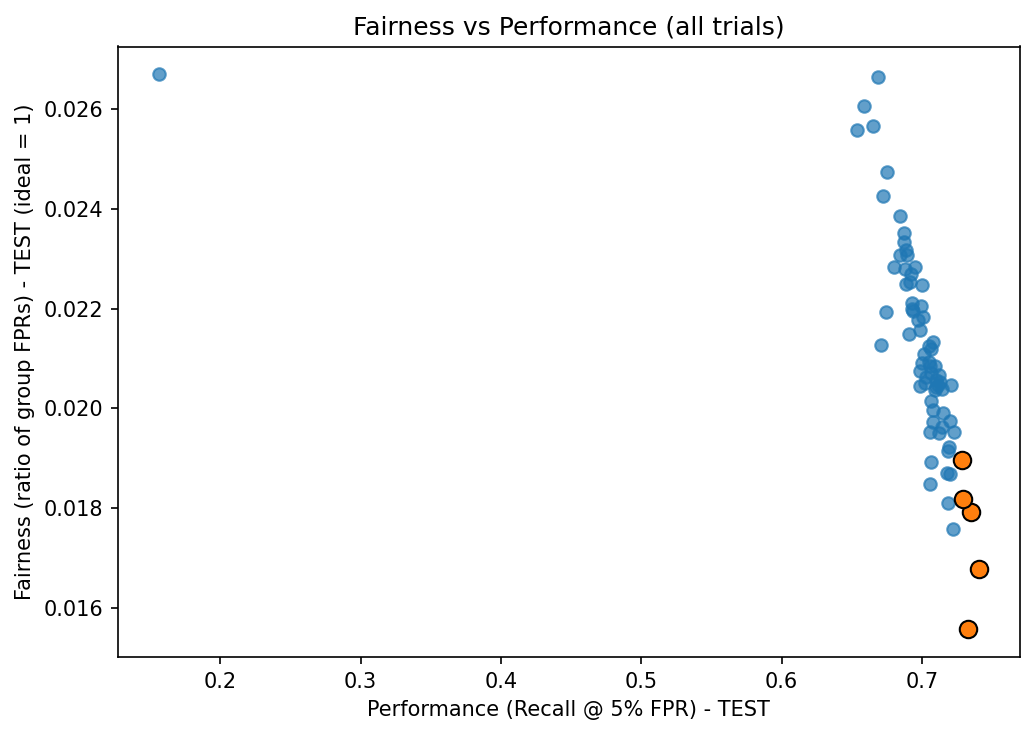

In [69]:
# 1) Full scatter of all trials.
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE, dpi=PLOT_DPI)
ax.scatter(fairness_results_df[perf_col], fairness_results_df[fair_col], alpha=0.7)

top_trials_by_recall = fairness_results_df.sort_values(perf_col, ascending=False).head(TOP_K_TRIALS)
ax.scatter(
    top_trials_by_recall[perf_col],
    top_trials_by_recall[fair_col],
    s=70,
    edgecolors="black",
)
ax.set_xlabel(f"Performance (Recall @ {int(FPR_CAP * 100)}% FPR) - {split_label}")
ax.set_ylabel(f"Fairness (ratio of group FPRs) - {split_label} (ideal = 1)")
ax.set_title("Fairness vs Performance (all trials)")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "fig_fairness_vs_performance.png", bbox_inches="tight")
print("Saved:", EXPORT_DIR / "fig_fairness_vs_performance.png")


## Block 34: Zoomed Fairness-Performance Scatter

Generates and saves a zoomed-in scatter focused on high-performance region.


Saved: snn_ftt_100_export_VIII/fig_fairness_vs_performance_zoom.png


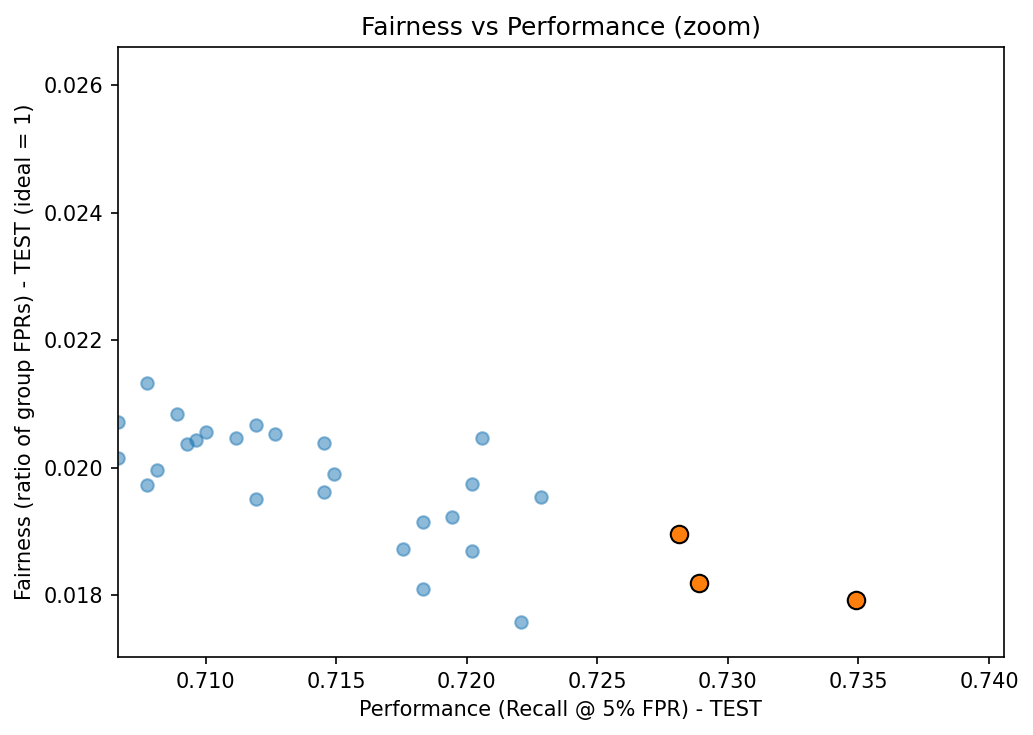

In [70]:
# 2) Zoom into high-performance region.
zoom_xmin = max(
    fairness_results_df[perf_col].min(),
    fairness_results_df[perf_col].quantile(ZOOM_X_QUANTILE),
)
zoom_xmax = fairness_results_df[perf_col].max()
zoom_ymin = fairness_results_df[fair_col].quantile(ZOOM_Y_LOW_QUANTILE)
zoom_ymax = fairness_results_df[fair_col].quantile(ZOOM_Y_HIGH_QUANTILE)

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE, dpi=PLOT_DPI)
ax.scatter(fairness_results_df[perf_col], fairness_results_df[fair_col], alpha=0.5)
ax.scatter(
    top_trials_by_recall[perf_col],
    top_trials_by_recall[fair_col],
    s=70,
    edgecolors="black",
)
ax.set_xlim(zoom_xmin, zoom_xmax + 1e-6)
ax.set_ylim(zoom_ymin - 1e-3, zoom_ymax + 1e-3)
ax.set_xlabel(f"Performance (Recall @ {int(FPR_CAP * 100)}% FPR) - {split_label}")
ax.set_ylabel(f"Fairness (ratio of group FPRs) - {split_label} (ideal = 1)")
ax.set_title("Fairness vs Performance (zoom)")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "fig_fairness_vs_performance_zoom.png", bbox_inches="tight")
print("Saved:", EXPORT_DIR / "fig_fairness_vs_performance_zoom.png")
